<a href="https://www.kaggle.com/code/lalit7881/paris-housing-prices-eda?scriptVersionId=313221454" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/paris-housing-prices/paris_housing_prices_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/paris-housing-prices/paris_housing_prices_dataset.csv")

In [3]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12


In [4]:
df.tail()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
1195,P11195,14,Studio,173,5,5,2010,Renovated,2.42,2328490.48
1196,P11196,16,Penthouse,192,4,1,1965,Good,6.56,2794554.47
1197,P11197,6,Loft,123,2,7,1961,New,13.18,2247682.75
1198,P11198,8,Studio,151,2,1,1926,Good,14.43,1236847.52
1199,P11199,7,Apartment,29,4,4,2018,Good,11.57,265630.92


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   object 
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   object 
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   object 
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 93.9+ KB


In [6]:
df.describe()

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Distance_to_Center_km,Price_EUR
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.0000,1200.000000,1.200000e+03
mean,10.81750,108.125833,3.000000,4.390833,1935.6725,7.755375,1.521459e+06
std,5.65811,54.176125,1.414214,2.899728,49.8934,4.179961,8.737896e+05
min,1.00000,15.000000,1.000000,0.000000,1850.0000,0.510000,1.205258e+05
25%,6.00000,62.000000,2.000000,2.000000,1894.0000,4.137500,7.847546e+05
50%,11.00000,108.000000,3.000000,4.000000,1935.0000,7.705000,1.430473e+06
75%,16.00000,157.000000,4.000000,7.000000,1977.0000,11.347500,2.125367e+06
max,20.00000,199.000000,5.000000,9.000000,2023.0000,14.990000,3.950832e+06


In [7]:
df.isnull().sum()

Property_ID              0
Arrondissement           0
Property_Type            0
Size_sqm                 0
Rooms                    0
Floor                    0
Year_Built               0
Condition                0
Distance_to_Center_km    0
Price_EUR                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Property_ID               object
Arrondissement             int64
Property_Type             object
Size_sqm                   int64
Rooms                      int64
Floor                      int64
Year_Built                 int64
Condition                 object
Distance_to_Center_km    float64
Price_EUR                float64
dtype: object

In [10]:
df.shape

(1200, 10)

In [11]:
df.columns

Index(['Property_ID', 'Arrondissement', 'Property_Type', 'Size_sqm', 'Rooms',
       'Floor', 'Year_Built', 'Condition', 'Distance_to_Center_km',
       'Price_EUR'],
      dtype='object')

In [12]:
df.nunique()

Property_ID              1200
Arrondissement             20
Property_Type               4
Size_sqm                  185
Rooms                       5
Floor                      10
Year_Built                174
Condition                   4
Distance_to_Center_km     805
Price_EUR                1200
dtype: int64

## EDA

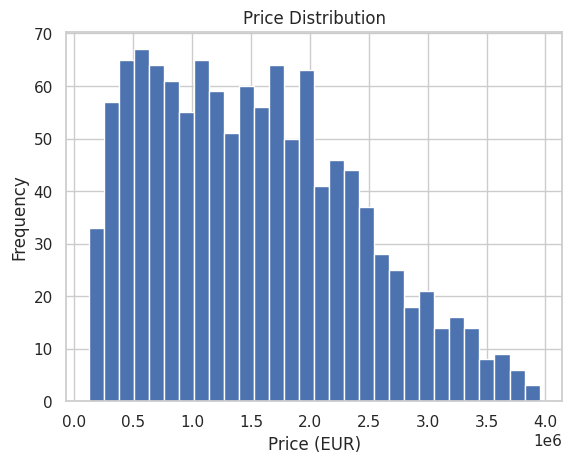

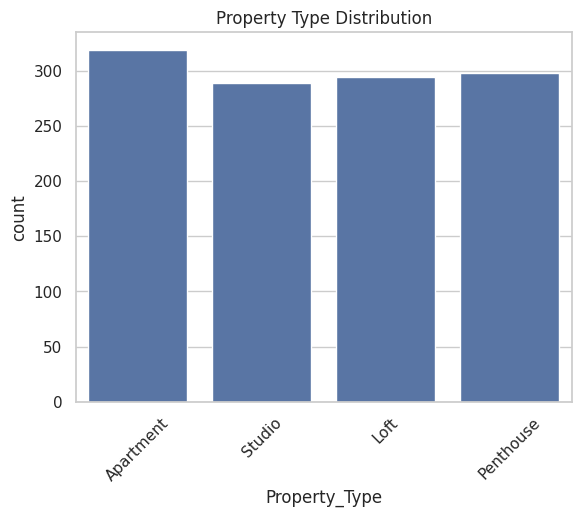

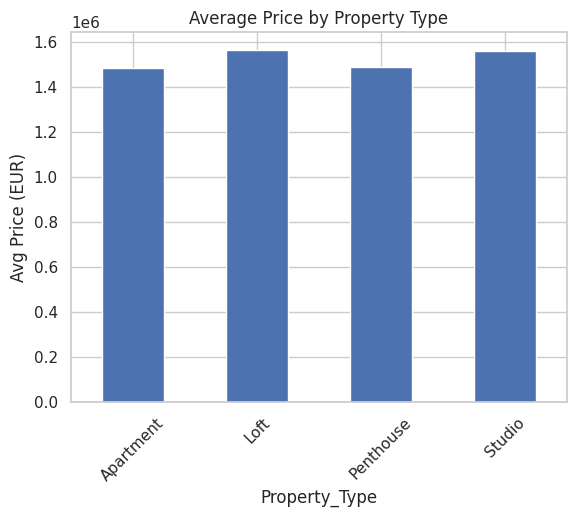

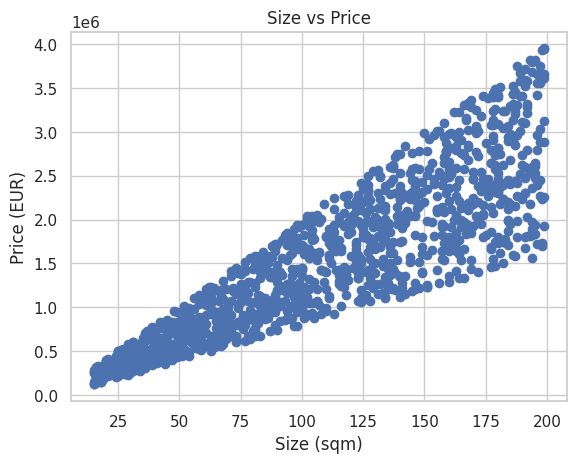

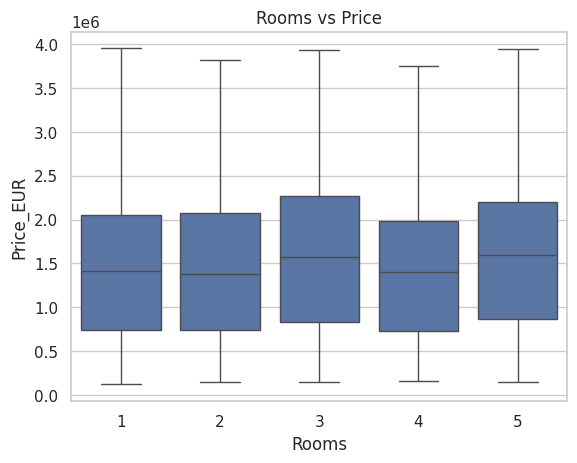

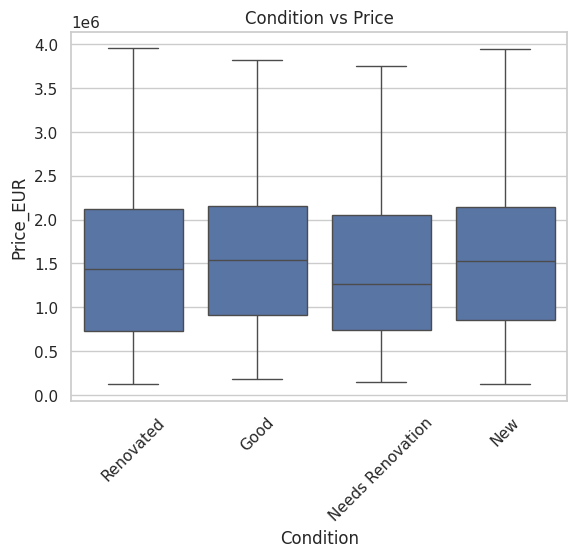

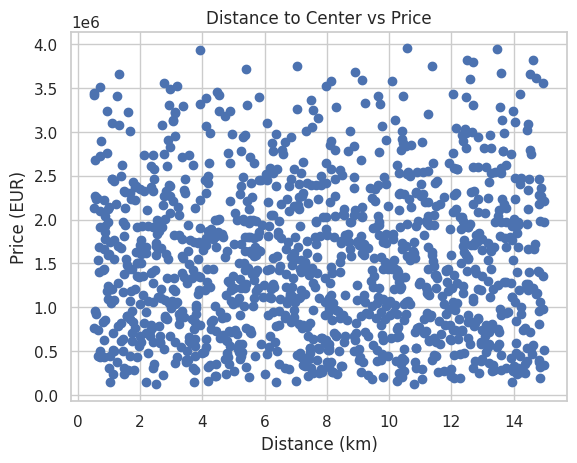

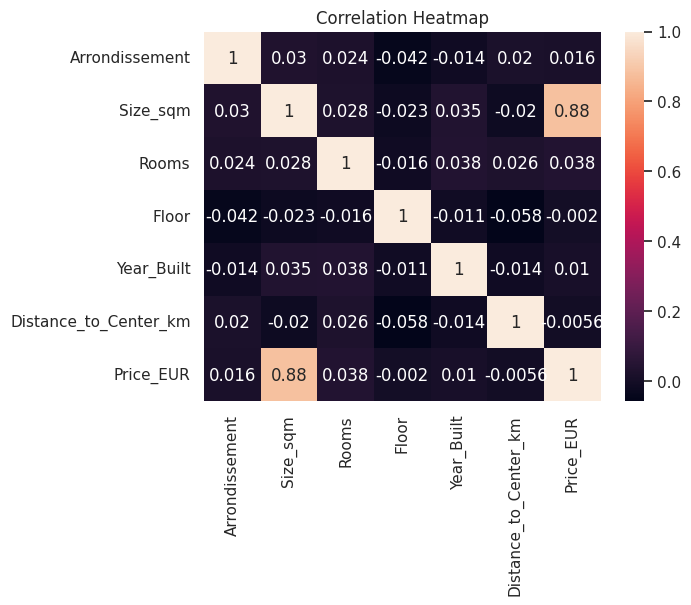

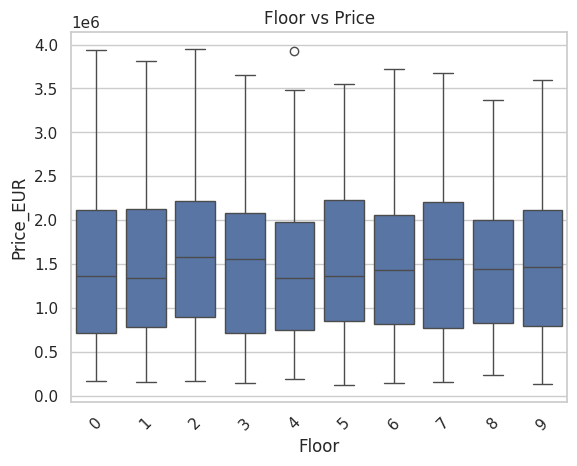

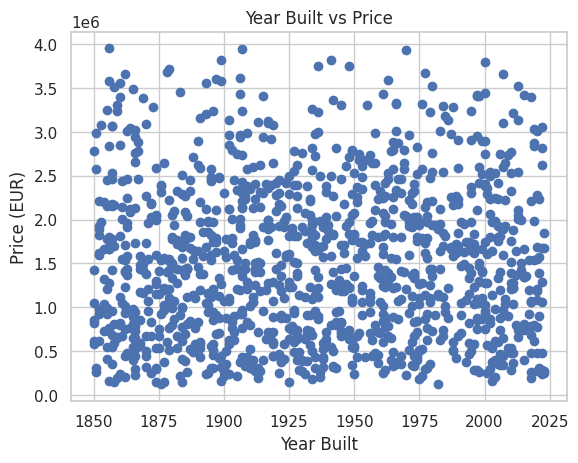

In [13]:
# Style
sns.set(style="whitegrid")

# -------------------------------
# 1. Price Distribution
# -------------------------------
plt.figure()
plt.hist(df['Price_EUR'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price (EUR)")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 2. Property Type Count
# -------------------------------
plt.figure()
sns.countplot(x='Property_Type', data=df)
plt.title("Property Type Distribution")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 3. Average Price by Property Type
# -------------------------------
plt.figure()
df.groupby('Property_Type')['Price_EUR'].mean().plot(kind='bar')
plt.title("Average Price by Property Type")
plt.ylabel("Avg Price (EUR)")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 4. Size vs Price Scatter
# -------------------------------
plt.figure()
plt.scatter(df['Size_sqm'], df['Price_EUR'])
plt.title("Size vs Price")
plt.xlabel("Size (sqm)")
plt.ylabel("Price (EUR)")
plt.show()

# -------------------------------
# 5. Rooms vs Price Boxplot
# -------------------------------
plt.figure()
sns.boxplot(x='Rooms', y='Price_EUR', data=df)
plt.title("Rooms vs Price")
plt.show()

# -------------------------------
# 6. Condition vs Price
# -------------------------------
plt.figure()
sns.boxplot(x='Condition', y='Price_EUR', data=df)
plt.title("Condition vs Price")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. Distance to Center vs Price
# -------------------------------
plt.figure()
plt.scatter(df['Distance_to_Center_km'], df['Price_EUR'])
plt.title("Distance to Center vs Price")
plt.xlabel("Distance (km)")
plt.ylabel("Price (EUR)")
plt.show()

# -------------------------------
# 8. Correlation Heatmap
# -------------------------------
plt.figure()
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 9. Floor vs Price
# -------------------------------
plt.figure()
sns.boxplot(x='Floor', y='Price_EUR', data=df)
plt.title("Floor vs Price")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 10. Year Built vs Price
# -------------------------------
plt.figure()
plt.scatter(df['Year_Built'], df['Price_EUR'])
plt.title("Year Built vs Price")
plt.xlabel("Year Built")
plt.ylabel("Price (EUR)")
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy: 0.8625

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86       120
           1       0.85      0.88      0.86       120

    accuracy                           0.86       240
   macro avg       0.86      0.86      0.86       240
weighted avg       0.86      0.86      0.86       240



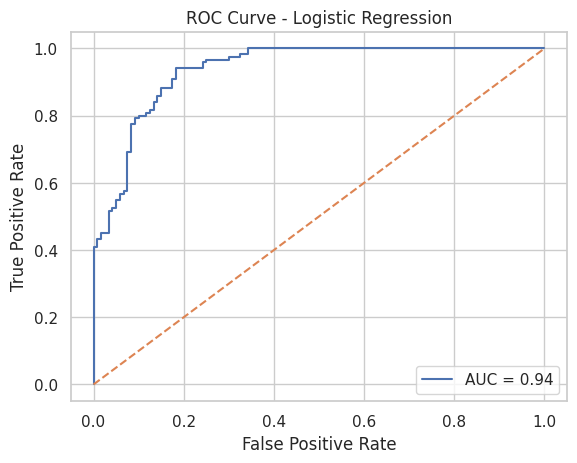


===== Random Forest =====
Accuracy: 0.8625

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       120
           1       0.85      0.88      0.87       120

    accuracy                           0.86       240
   macro avg       0.86      0.86      0.86       240
weighted avg       0.86      0.86      0.86       240



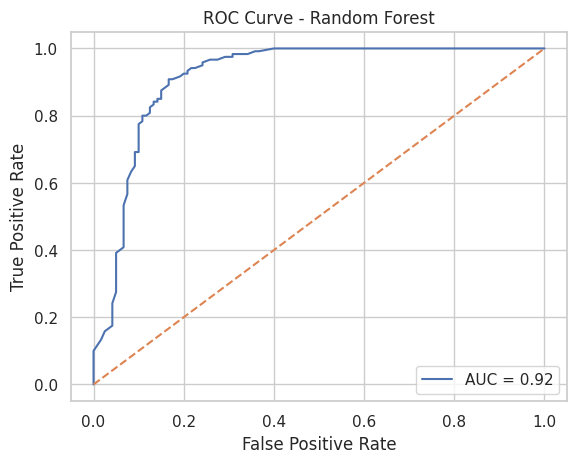

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

median_price = df['Price_EUR'].median()
df['Target'] = (df['Price_EUR'] > median_price).astype(int)

# Drop ID (not useful)
df = df.drop(columns=['Property_ID'])

# -------------------------------
# 3. Features & Target
# -------------------------------
X = df.drop(columns=['Price_EUR', 'Target'])
y = df['Target']

# -------------------------------
# 4. Train-Test Split (NO LEAKAGE)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 5. Preprocessing
# -------------------------------
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# -------------------------------
# 6. Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# -------------------------------
# 7. Train, Evaluate, ROC
# -------------------------------
for name, model in models.items():
    print(f"\n===== {name} =====")

    # Pipeline (preprocessing + model)
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Train ONLY on training data
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Classification report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you...pls upvote!!!!!!!!!